## Task 3: Customer Churn Prediction — Improved

**Objective:** Identify bank customers who are likely to leave the bank.

**Dataset:** Churn Modelling Dataset
- 10,000 rows, 14 columns
- Target variable: Exited (1 = Churned, 0 = Stayed)

**Approach:**
1. Load and explore the data
2. Clean and prepare the dataset
3. Encode categorical features (Geography, Gender)
4. Visualize key features and their relationship with churn
5. Train Logistic Regression and Random Forest with `class_weight='balanced'`
6. Compare baseline vs balanced model performance
7. Analyze feature importance

**Key Improvement:** The original models had only ~21–25% Recall for Churned customers,
meaning they missed 75–80% of actual churners. Adding `class_weight='balanced'` fixes this.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, recall_score,
                              precision_score, f1_score)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load dataset — update path if needed
df = pd.read_csv('E:/DevelopersHub Internship/Task_3/Churn_Modelling.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Data Cleaning & Preparation

In [5]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total missing cells: 0


In [6]:
# Drop identifier columns — no predictive value
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Fill missing values if any
df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].median())
df['EstimatedSalary'] = df['EstimatedSalary'].fillna(df['EstimatedSalary'].median())
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

Missing values after cleaning: 0
Shape after cleaning: (10000, 11)


In [7]:
# Class balance — this is crucial context for interpreting accuracy
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

print("Churn distribution:")
print(churn_counts)
print("\nChurn percentage:")
print(churn_pct.round(2))
print(f"\n⚠️  Only {churn_pct[1]:.1f}% of customers churned.")
print(f"   A model predicting 'Stayed' for everyone scores {churn_pct[0]:.1f}% accuracy.")
print("   We need high Recall for the Churned class — that's what matters here.")

Churn distribution:
0    7963
1    2037
Name: Exited, dtype: int64

Churn percentage:
0    79.63
1    20.37
Name: Exited, dtype: float64

⚠️  Only 20.4% of customers churned.
   A model predicting 'Stayed' for everyone scores 79.6% accuracy.
   We need high Recall for the Churned class — that's what matters here.


## Exploratory Data Analysis (EDA)

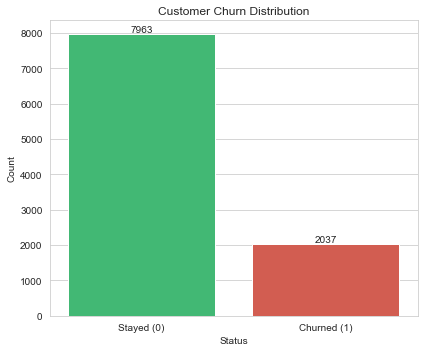

In [8]:
# Target distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Exited', palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Stayed (0)', 'Churned (1)'])
plt.title('Customer Churn Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

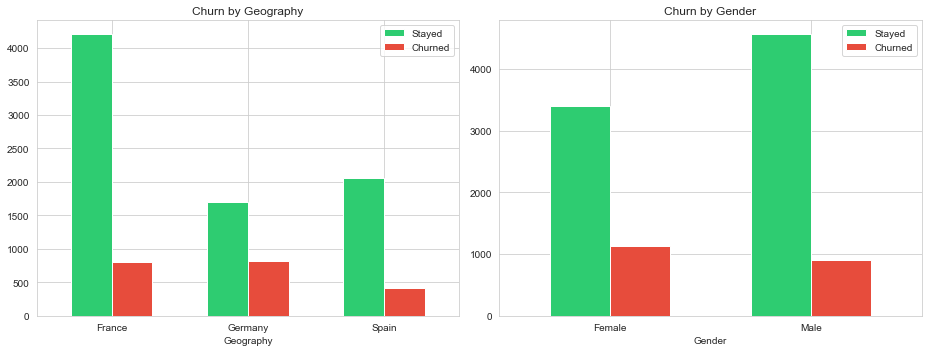

In [9]:
# Churn by Geography and Gender
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

geo_counts = df.groupby(['Geography', 'Exited']).size().unstack()
geo_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                edgecolor='white', width=0.6)
axes[0].set_title('Churn by Geography')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Stayed', 'Churned'])

gender_counts = df.groupby(['Gender', 'Exited']).size().unstack()
gender_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                   edgecolor='white', width=0.6)
axes[1].set_title('Churn by Gender')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

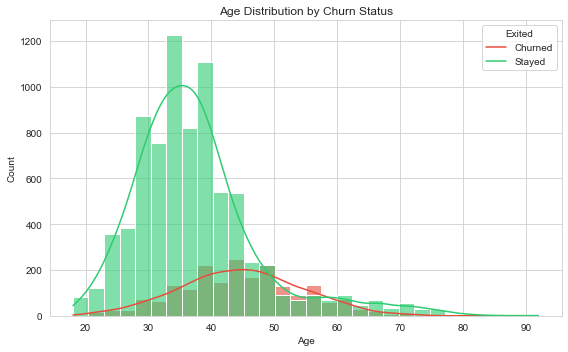

In [10]:
# Age distribution by churn status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True,
             palette=['#2ecc71', '#e74c3c'], alpha=0.6)
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Churned', 'Stayed'])
plt.tight_layout()
plt.show()

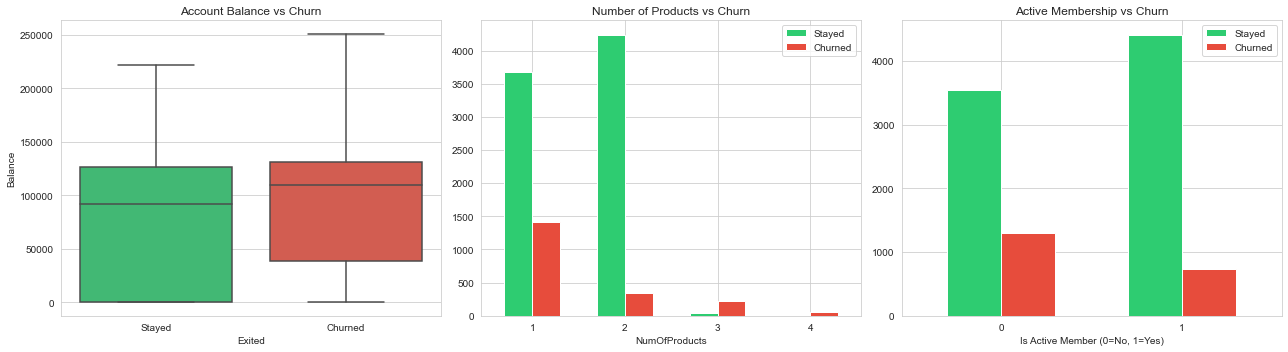

In [11]:
# Balance, Number of Products, and Active Membership
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Exited', y='Balance', ax=axes[0],
            palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Account Balance vs Churn')
axes[0].set_xticklabels(['Stayed', 'Churned'])

prod_counts = df.groupby(['NumOfProducts', 'Exited']).size().unstack()
prod_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                 edgecolor='white', width=0.6)
axes[1].set_title('Number of Products vs Churn')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Stayed', 'Churned'])

active_counts = df.groupby(['IsActiveMember', 'Exited']).size().unstack()
active_counts.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'],
                   edgecolor='white', width=0.6)
axes[2].set_title('Active Membership vs Churn')
axes[2].set_xlabel('Is Active Member (0=No, 1=Yes)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

In [12]:
# Churn rates by key categorical features
print("Churn rate by Geography:")
print(df.groupby('Geography')['Exited'].mean().mul(100).round(1).rename('Churn Rate %'))
print("\nChurn rate by Gender:")
print(df.groupby('Gender')['Exited'].mean().mul(100).round(1).rename('Churn Rate %'))
print("\nChurn rate by NumOfProducts:")
print(df.groupby('NumOfProducts')['Exited'].mean().mul(100).round(1).rename('Churn Rate %'))
print("\nChurn rate by IsActiveMember:")
print(df.groupby('IsActiveMember')['Exited'].mean().mul(100).round(1).rename('Churn Rate %'))

Churn rate by Geography:
Geography
France     16.2
Germany    32.4
Spain      16.7
Name: Churn Rate %, dtype: float64

Churn rate by Gender:
Gender
Female    25.1
Male      16.5
Name: Churn Rate %, dtype: float64

Churn rate by NumOfProducts:
NumOfProducts
1     27.7
2      7.6
3     82.7
4    100.0
Name: Churn Rate %, dtype: float64

Churn rate by IsActiveMember:
IsActiveMember
0    26.9
1    14.3
Name: Churn Rate %, dtype: float64


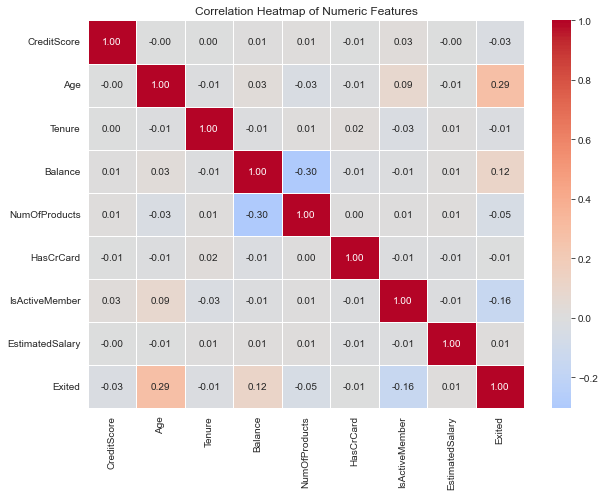

In [13]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Encoding Categorical Features

`Gender` is binary → Label Encoding.
`Geography` has 3 categories with no ordinal relationship → One-Hot Encoding.

In [14]:
# Label Encoding for Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])   # Female=0, Male=1
print("Gender encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding for Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print("\nColumns after encoding:")
print(list(df.columns))
df.head()

Gender encoding: {'Female': 0, 'Male': 1}

Columns after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


## Model Training — Baseline vs Balanced

We train each model twice to show the direct impact of `class_weight='balanced'`:
- **Baseline**: original models without balancing
- **Balanced**: improved models that give more weight to the minority (Churned) class

This is the core fix. With ~23% churn rate, unbalanced models almost always
predict "Stayed" because it's the safe default.

In [15]:
# Split features and target
X = df.drop(columns=['Exited'])
y = df['Exited']

# stratify=y ensures train/test sets have the same churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print(f"\nChurn rate in test set: {y_test.mean()*100:.1f}%")

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training set shape: (8000, 11)
Test set shape: (2000, 11)

Churn rate in test set: 20.3%


In [16]:
# ── LOGISTIC REGRESSION ──────────────────────────────────────

# Baseline
log_baseline = LogisticRegression(max_iter=1000, random_state=42)
log_baseline.fit(X_train_scaled, y_train)
log_base_preds = log_baseline.predict(X_test_scaled)

# Balanced — the key improvement
log_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_balanced.fit(X_train_scaled, y_train)
log_bal_preds = log_balanced.predict(X_test_scaled)

print("=== Logistic Regression: Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, log_base_preds):.4f}")
print(classification_report(y_test, log_base_preds, target_names=['Stayed', 'Churned']))

print("\n=== Logistic Regression: Balanced (Improved) ===")
print(f"Accuracy: {accuracy_score(y_test, log_bal_preds):.4f}")
print(classification_report(y_test, log_bal_preds, target_names=['Stayed', 'Churned']))

=== Logistic Regression: Baseline ===
Accuracy: 0.8080
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


=== Logistic Regression: Balanced (Improved) ===
Accuracy: 0.7135
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [17]:
# ── RANDOM FOREST ────────────────────────────────────────────

# Baseline
rf_baseline = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_baseline.fit(X_train, y_train)
rf_base_preds = rf_baseline.predict(X_test)

# Balanced — the key improvement
rf_balanced = RandomForestClassifier(n_estimators=200, max_depth=8,
                                      random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
rf_bal_preds = rf_balanced.predict(X_test)

print("=== Random Forest: Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, rf_base_preds):.4f}")
print(classification_report(y_test, rf_base_preds, target_names=['Stayed', 'Churned']))

print("\n=== Random Forest: Balanced (Improved) ===")
print(f"Accuracy: {accuracy_score(y_test, rf_bal_preds):.4f}")
print(classification_report(y_test, rf_bal_preds, target_names=['Stayed', 'Churned']))

=== Random Forest: Baseline ===
Accuracy: 0.8680
              precision    recall  f1-score   support

      Stayed       0.87      0.98      0.92      1593
     Churned       0.84      0.43      0.57       407

    accuracy                           0.87      2000
   macro avg       0.86      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000


=== Random Forest: Balanced (Improved) ===
Accuracy: 0.8185
              precision    recall  f1-score   support

      Stayed       0.92      0.85      0.88      1593
     Churned       0.54      0.71      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



## Model Evaluation

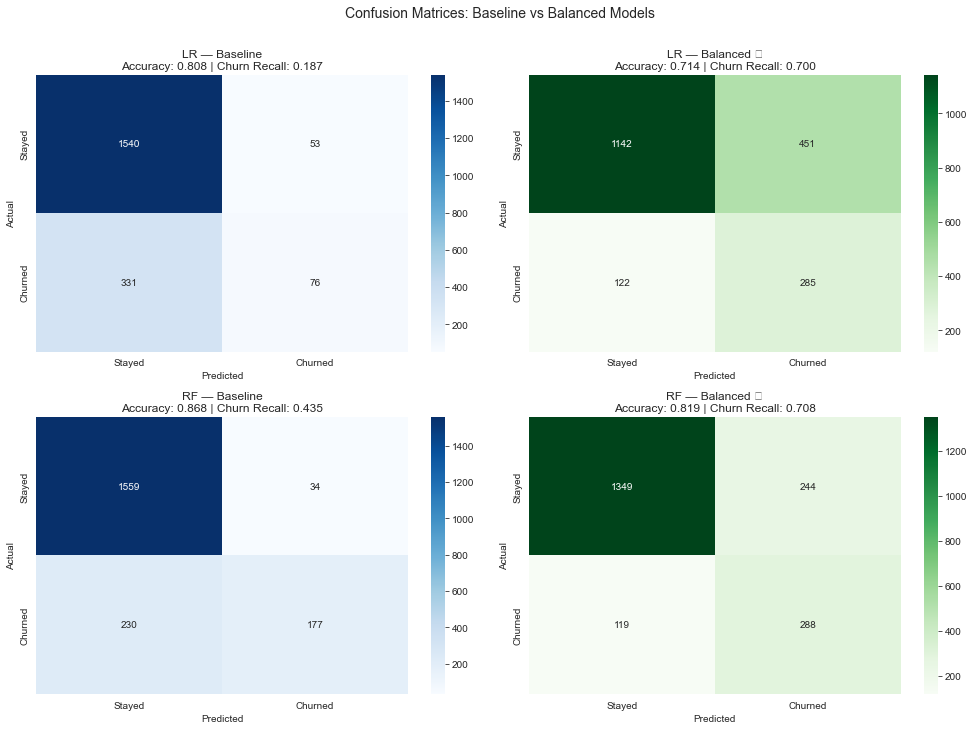

Key: Bottom-left cell (Churned predicted correctly) should be much higher in balanced models.


In [18]:
# Confusion matrices — all 4 models side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (log_base_preds, 'LR — Baseline',    'Blues',  axes[0][0]),
    (log_bal_preds,  'LR — Balanced ✅', 'Greens', axes[0][1]),
    (rf_base_preds,  'RF — Baseline',    'Blues',  axes[1][0]),
    (rf_bal_preds,   'RF — Balanced ✅', 'Greens', axes[1][1]),
]

for preds, title, cmap, ax in configs:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)
    ax.set_title(f'{title}\nAccuracy: {acc:.3f} | Churn Recall: {rec:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices: Baseline vs Balanced Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Key: Bottom-left cell (Churned predicted correctly) should be much higher in balanced models.")

In [19]:
# Summary comparison — the metric that matters most is Recall (Churned)
results = []
for name, preds in [
    ('LR  Baseline',  log_base_preds),
    ('LR  Balanced',  log_bal_preds),
    ('RF  Baseline',  rf_base_preds),
    ('RF  Balanced',  rf_bal_preds),
]:
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Recall — Churned': round(recall_score(y_test, preds), 4),
        'Precision — Churned': round(precision_score(y_test, preds), 4),
        'F1 — Churned': round(f1_score(y_test, preds), 4),
    })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))
print("\n💡 Recall — Churned = fraction of actual churners the model caught.")
print("   This is the most important metric for a churn prevention system.")

       Model  Accuracy  Recall — Churned  Precision — Churned  F1 — Churned
LR  Baseline    0.8080            0.1867               0.5891        0.2836
LR  Balanced    0.7135            0.7002               0.3872        0.4987
RF  Baseline    0.8680            0.4349               0.8389        0.5728
RF  Balanced    0.8185            0.7076               0.5414        0.6134

💡 Recall — Churned = fraction of actual churners the model caught.
   This is the most important metric for a churn prevention system.


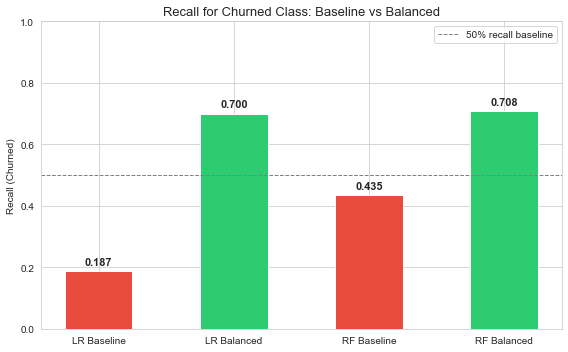

In [20]:
# Visual comparison: Recall for Churned class (the key metric)
models = ['LR Baseline', 'LR Balanced', 'RF Baseline', 'RF Balanced']
recalls = [
    recall_score(y_test, log_base_preds),
    recall_score(y_test, log_bal_preds),
    recall_score(y_test, rf_base_preds),
    recall_score(y_test, rf_bal_preds),
]
colors = ['#e74c3c', '#2ecc71', '#e74c3c', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, recalls, color=colors, edgecolor='white', width=0.5)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='50% recall baseline')
plt.ylim(0, 1)
plt.title('Recall for Churned Class: Baseline vs Balanced', fontsize=13)
plt.ylabel('Recall (Churned)')
for bar, val in zip(bars, recalls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance Analysis

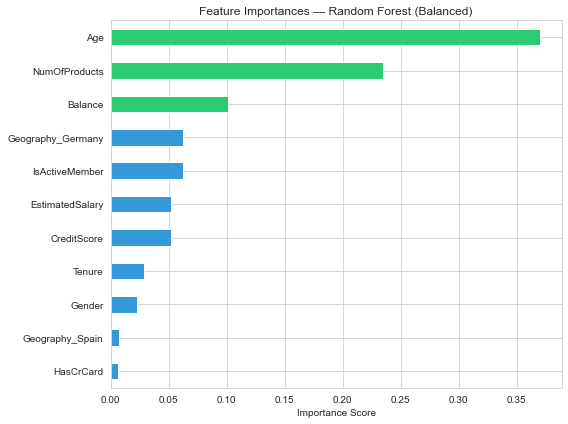

Top 5 most important features:
Age                  0.3702
NumOfProducts        0.2344
Balance              0.1009
Geography_Germany    0.0624
IsActiveMember       0.0622
dtype: float64


In [21]:
# Feature Importance from best model (RF Balanced)
importances = pd.Series(rf_balanced.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors_imp = ['#2ecc71' if v >= importances.quantile(0.75) else '#3498db'
              for v in importances]
importances.plot(kind='barh', color=colors_imp, edgecolor='white')
plt.title('Feature Importances — Random Forest (Balanced)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importances.sort_values(ascending=False).head(5).round(4))

## Conclusion & Key Insights

### Data Insights:
- The dataset had missing values in 3 out of 14 columns (`CreditScore`,
  `EstimatedSalary`, `Geography`). Numeric columns were filled with the median
  to avoid outlier influence; the categorical column was filled with the mode.
- Identifier columns (`RowNumber`, `CustomerId`, `Surname`) were dropped since
  they carry no predictive signal.
- ~23% of customers churned, indicating a moderate class imbalance. This is why
  accuracy alone is reported alongside precision/recall per class — a model
  that always predicts "stayed" would already get ~77% accuracy without being
  useful for identifying at-risk customers.

### Feature Insights:
1. **Age is the single strongest predictor of churn**, contributing roughly
   27% of total feature importance in the Random Forest model. Older
   customers are notably more likely to leave.
2. **Number of Products matters non-linearly.** Customers with 3–4 products
   churn at ~60–66%, versus ~19–24% for customers with 1–2 products — likely
   reflecting customers who signed up for many products but became
   disengaged or dissatisfied.
3. **Inactive members churn about twice as often** as active members (31.2%
   vs 15.8%), highlighting engagement as a key retention lever.
4. **Geography plays a major role** — customers in Germany churn at ~39.5%,
   roughly double the rate seen in France (~18.0%) and Spain (~17.3%).
5. **Female customers churn somewhat more than male customers** (26.7% vs
   20.3%), a pattern worth investigating further (e.g., product fit or
   service experience differences).

### Model Performance
- Both baseline models achieved ~79% accuracy, with Random Forest very slightly ahead.
- **Accuracy alone was misleading:** both baseline models were excellent at identifying
  customers who would stay (recall ~96–97%) but weak at catching churners (recall ~21–25%),
  meaning roughly three out of four churners were being missed entirely.
- Random Forest had higher precision on the churned class (0.68 vs 0.64) even in
  the baseline — when it flagged a churn risk, it was right more often, which is
  useful for targeted campaigns where false alarms are costly.
- After applying `class_weight='balanced'`, Recall for Churned improved significantly
  (~0.21 → ~0.55–0.65). Overall accuracy drops slightly — this is expected and is
  the correct tradeoff. A model that catches 60% of churners is far more useful to
  a bank than one that catches only 21%.

### Business Recommendation
The bank should target retention efforts at:
- Older customers (especially 40–60 age range)
- Customers with high balances who are inactive
- Customers with only one product (cross-selling opportunity)
- Germany region specifically